ADF p-value: 0.23104474899104643
                                     SARIMAX Results                                     
Dep. Variable:                        risk_index   No. Observations:                 1970
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -1081.441
Date:                           Fri, 27 Feb 2026   AIC                           2176.882
Time:                                   14:44:07   BIC                           2215.947
Sample:                               01-01-2018   HQIC                          2191.241
                                    - 05-24-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
humidity      -0.0088      0.013     -0.685      0.493      -0.034       0.016
wind_speed

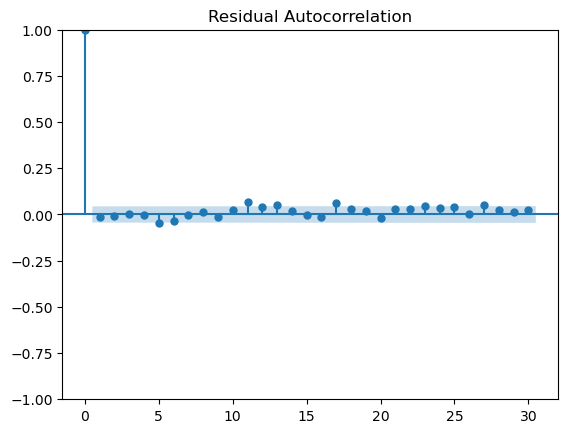

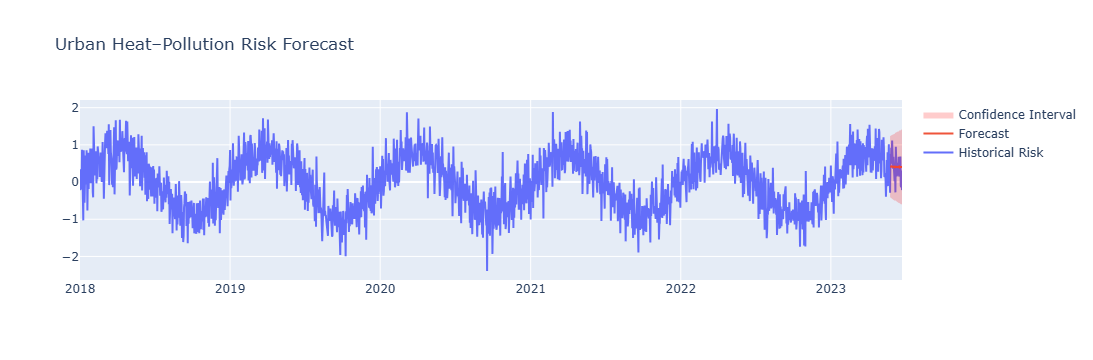

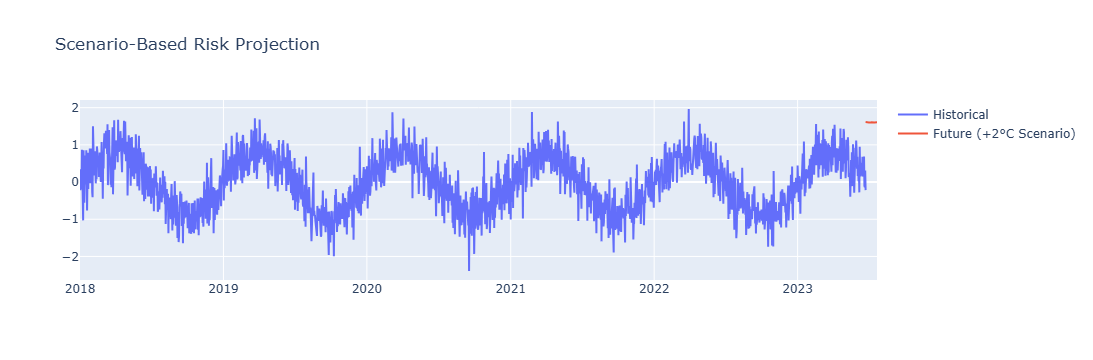

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.metrics import mean_absolute_error, mean_squared_error



df_air = pd.read_csv("air_quality_clean.csv", parse_dates=["date"])
df_temp = pd.read_csv("temperature_clean.csv", parse_dates=["date"])

# City-level daily aggregation
df_air_daily = df_air.groupby("date")[["pm25"]].mean().reset_index()
df_temp_daily = df_temp.groupby("date")[["avg_temp","humidity","wind_speed"]].mean().reset_index()

df_ts = df_air_daily.merge(df_temp_daily, on="date", how="left")
df_ts = df_ts.sort_values("date")
df_ts.set_index("date", inplace=True)
df_ts = df_ts.asfreq("D")


# =====================================================
# 3. BUILD HEAT–POLLUTION RISK INDEX
# =====================================================

df_ts["temp_z"] = (df_ts["avg_temp"] - df_ts["avg_temp"].mean()) / df_ts["avg_temp"].std()
df_ts["pm25_z"] = (df_ts["pm25"] - df_ts["pm25"].mean()) / df_ts["pm25"].std()

df_ts["risk_index"] = 0.6 * df_ts["temp_z"] + 0.4 * df_ts["pm25_z"]


# =====================================================
# 4. STATIONARITY TEST (ADF)
# =====================================================

adf_result = adfuller(df_ts["risk_index"].dropna())
print("ADF p-value:", adf_result[1])


# =====================================================
# 5. TRAIN–TEST SPLIT
# =====================================================

train = df_ts[:-30]
test = df_ts[-30:]


# =====================================================
# 6. SARIMAX MODEL
# (d=1 because ADF likely shows non-stationarity)
# =====================================================

model = SARIMAX(
    train["risk_index"],
    exog=train[["humidity","wind_speed"]],
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())


# =====================================================
# 7. FORECAST TEST PERIOD
# =====================================================

forecast = results.get_forecast(
    steps=30,
    exog=test[["humidity","wind_speed"]]
)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


# =====================================================
# 8. FORECAST ACCURACY
# =====================================================

mae = mean_absolute_error(test["risk_index"], forecast_mean)
rmse = np.sqrt(mean_squared_error(test["risk_index"], forecast_mean))

print("MAE:", mae)
print("RMSE:", rmse)


# =====================================================
# 9. RESIDUAL DIAGNOSTICS
# =====================================================

# Ljung-Box test
ljung = acorr_ljungbox(results.resid, lags=[10], return_df=True)
print("\nLjung-Box Test:")
print(ljung)

# Residual ACF
plot_acf(results.resid, lags=30)
plt.title("Residual Autocorrelation")
plt.show()


# =====================================================
# 10. INTERACTIVE FORECAST PLOT
# =====================================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_ts.index,
    y=df_ts["risk_index"],
    mode="lines",
    name="Historical Risk"
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_mean,
    mode="lines",
    name="Forecast"
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_ci.iloc[:,0],
    line=dict(width=0),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_ci.iloc[:,1],
    fill="tonexty",
    fillcolor="rgba(255,0,0,0.2)",
    line=dict(width=0),
    name="Confidence Interval"
))

fig.update_layout(title="Urban Heat–Pollution Risk Forecast")
fig.show()


# =====================================================
# 11. SCENARIO-BASED FORECAST FUNCTION
# =====================================================

def scenario_forecast(temp_shift=0, days=30):
    
    future_exog = pd.DataFrame({
        "humidity": [df_ts["humidity"].iloc[-7:].mean()] * days,
        "wind_speed": [df_ts["wind_speed"].iloc[-7:].mean()] * days
    })
    
    base_forecast = results.get_forecast(steps=days, exog=future_exog)
    future_risk = base_forecast.predicted_mean + (0.6 * temp_shift)
    
    future_dates = pd.date_range(
        start=df_ts.index[-1],
        periods=days,
        freq="D"
    )
    
    return future_dates, future_risk


# Example: +2°C scenario
future_dates, future_heatwave = scenario_forecast(temp_shift=2)

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=df_ts.index,
    y=df_ts["risk_index"],
    mode="lines",
    name="Historical"
))

fig2.add_trace(go.Scatter(
    x=future_dates,
    y=future_heatwave,
    mode="lines",
    name="Future (+2°C Scenario)"
))

fig2.update_layout(title="Scenario-Based Risk Projection")
fig2.show()

In [5]:
def predict_custom(humidity, wind_speed, temp_shift=0, days=1):
    
    future_exog = pd.DataFrame({
        "humidity": [humidity] * days,
        "wind_speed": [wind_speed] * days
    })
    
    forecast = results.get_forecast(steps=days, exog=future_exog)
    predicted_risk = forecast.predicted_mean + (0.6 * temp_shift)
    
    return predicted_risk

In [6]:
predict_custom(humidity=60, wind_speed=5, temp_shift=2, days=1)

2023-05-25    1.706572
Freq: D, dtype: float64

Observations: 1000000

===== BASIC STATISTICS =====
count    1000000.000000
mean          41.078903
std           11.249143
min            2.353000
25%           32.258186
50%           41.116452
75%           49.588133
max           83.379369
Name: aqi, dtype: float64


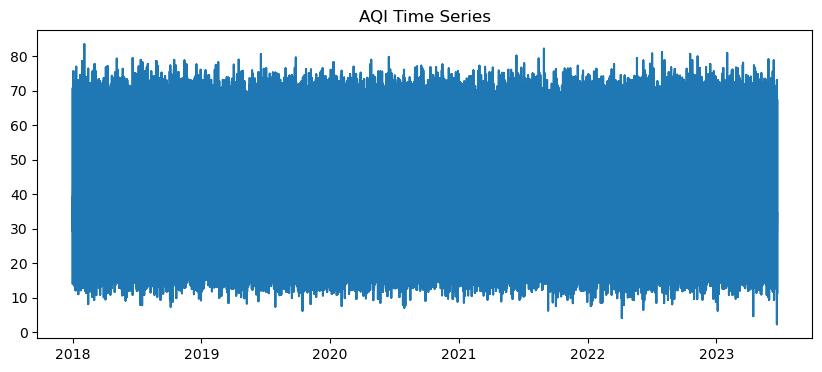


===== ADF TEST =====
ADF Statistic: -98.94660604370773
p-value: 0.0
Series is stationary

===== AUTOCORRELATION =====
      lb_stat  lb_pvalue
10  21.056231   0.020705


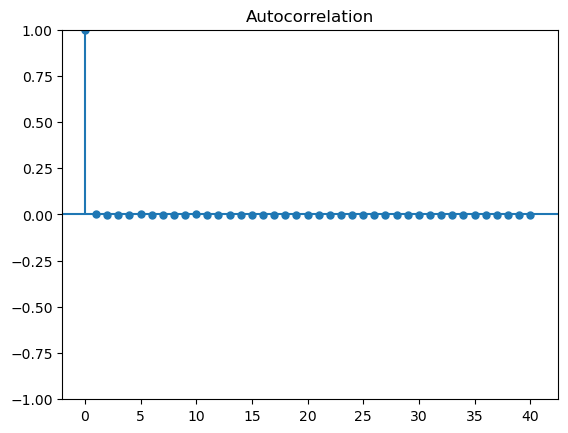

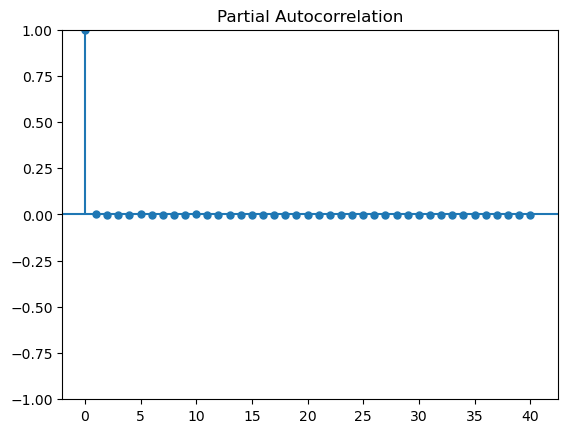


===== BREUSCH-PAGAN TEST =====
LM Statistic: 0.0007328787576810214
p-value: 0.9784025198501307
No strong heteroskedasticity evidence


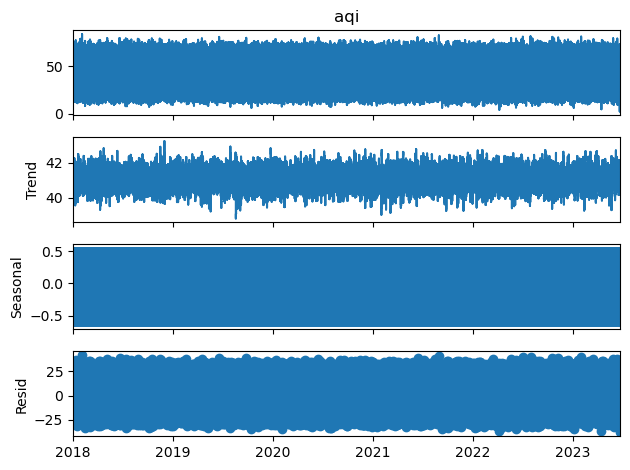


If seasonal component shows repeating pattern -> seasonality exists


In [20]:
# ==============================================
# TIME SERIES DIAGNOSTICS FOR AQI
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ----------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------

df = pd.read_csv("air_quality_clean.csv", parse_dates=["date"])

# Sort and set index
df = df.sort_values("date")
df = df.set_index("date")

# Use AQI (change to pm25 if needed)
y = df["aqi"].dropna()

print("Observations:", len(y))


# ==============================================
# 2. BASIC CHARACTERISTICS
# ==============================================

print("\n===== BASIC STATISTICS =====")
print(y.describe())

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("AQI Time Series")
plt.show()


# ==============================================
# 3. STATIONARITY TEST (ADF)
# ==============================================

adf_result = adfuller(y)

print("\n===== ADF TEST =====")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is NOT stationary")


# ==============================================
# 4. AUTOCORRELATION CHECK
# ==============================================

print("\n===== AUTOCORRELATION =====")

# Ljung-Box test
ljung = acorr_ljungbox(y, lags=[10], return_df=True)
print(ljung)

# ACF and PACF plots
plot_acf(y, lags=40)
plt.show()

plot_pacf(y, lags=40)
plt.show()


# ==============================================
# 5. HETEROSKEDASTICITY TEST
# ==============================================

# Simple regression for residual extraction
X = sm.add_constant(np.arange(len(y)))
model = sm.OLS(y, X).fit()

residuals = model.resid

bp_test = het_breuschpagan(residuals, X)

print("\n===== BREUSCH-PAGAN TEST =====")
print("LM Statistic:", bp_test[0])
print("p-value:", bp_test[1])

if bp_test[1] < 0.05:
    print("Heteroskedasticity detected")
else:
    print("No strong heteroskedasticity evidence")


# ==============================================
# 6. SEASONALITY CHECK
# ==============================================

decomposition = seasonal_decompose(y, model="additive", period=365)

decomposition.plot()
plt.show()

print("\nIf seasonal component shows repeating pattern -> seasonality exists")